In [ ]:
#Step 1 Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler ,LabelEncoder
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report
import pickle

In [ ]:
#Step 2 Load Data

In [2]:
df=pd.read_csv("realistic_renewal_data_300.csv")
df

,Customer_ID,Serial_No,Product_Type,Contract_Status,Contract_Start,Contract_End,Support_Package,Warranty,Last_Year_Discount,Previous_Contracts,Renewal
0,C0001,S01001,Monitor,Active,2021-08-14,2023-08-18,Basic,Yes,18,4,Yes
1,C0002,S01002,Laptop,Expired,2020-11-21,2021-12-28,Standard,No,17,0,No
2,C0003,S01003,Monitor,Active,2022-12-21,2024-12-11,Premium,Yes,16,0,No
3,C0004,S01004,Monitor,Active,2022-07-15,2024-03-11,Standard,No,11,3,No
4,C0005,S01005,Laptop,Expired,2022-12-11,2024-01-12,Standard,No,6,3,No
...,...,...,...,...,...,...,...,...,...,...,...
295,C0296,S01296,Printer,Expired,2022-05-15,2024-05-19,Standard,Yes,15,3,No
296,C0297,S01297,Printer,Expired,2022-06-06,2024-02-08,Premium,Yes,9,2,Yes
297,C0298,S01298,Printer,Expired,2021-05-02,2022-06-22,Standard,No,19,0,No
298,C0299,S01299,Printer,Active,2020-07-31,2022-12-22,Premium,No,9,0,No


In [3]:
df.head(5)

,Customer_ID,Serial_No,Product_Type,Contract_Status,Contract_Start,Contract_End,Support_Package,Warranty,Last_Year_Discount,Previous_Contracts,Renewal
0,C0001,S01001,Monitor,Active,2021-08-14,2023-08-18,Basic,Yes,18,4,Yes
1,C0002,S01002,Laptop,Expired,2020-11-21,2021-12-28,Standard,No,17,0,No
2,C0003,S01003,Monitor,Active,2022-12-21,2024-12-11,Premium,Yes,16,0,No
3,C0004,S01004,Monitor,Active,2022-07-15,2024-03-11,Standard,No,11,3,No
4,C0005,S01005,Laptop,Expired,2022-12-11,2024-01-12,Standard,No,6,3,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Customer_ID         300 non-null    object
 1   Serial_No           300 non-null    object
 2   Product_Type        300 non-null    object
 3   Contract_Status     300 non-null    object
 4   Contract_Start      300 non-null    object
 5   Contract_End        300 non-null    object
 6   Support_Package     300 non-null    object
 7   Warranty            300 non-null    object
 8   Last_Year_Discount  300 non-null    int64 
 9   Previous_Contracts  300 non-null    int64 
 10  Renewal             300 non-null    object
dtypes: int64(2), object(9)
memory usage: 25.9+ KB


In [4]:
df.describe()

,Last_Year_Discount,Previous_Contracts
count,300.000000,300.000000
mean,14.573333,2.406667
std,5.758631,1.719830
min,5.000000,0.000000
25%,10.000000,1.000000
50%,15.000000,2.000000
75%,19.000000,4.000000
max,24.000000,5.000000


In [5]:
df["Renewal"].value_counts()

Renewal
No     176
Yes    124
Name: count, dtype: int64

In [ ]:
#Step 3 feature engineering

In [6]:
# Convert dates
df["Contract_Start"] = pd.to_datetime(df["Contract_Start"])
df["Contract_End"] = pd.to_datetime(df["Contract_End"])

# Create new features
df["Contract_Duration"] = (df["Contract_End"] - df["Contract_Start"]).dt.days

df["Is_Long_Contract"] = (df["Contract_Duration"] > 365).astype(int)
df["High_Discount"] = (df["Last_Year_Discount"] > 15).astype(int)
df["Loyal_Customer"] = (df["Previous_Contracts"] >= 3).astype(int)

# Drop date columns
df = df.drop(["Contract_Start", "Contract_End"], axis=1)


In [7]:
for col in df.columns:
    print(col, df[col].unique())
    print("-"*50)

Customer_ID ['C0001' 'C0002' 'C0003' 'C0004' 'C0005' 'C0006' 'C0007' 'C0008' 'C0009'
 'C0010' 'C0011' 'C0012' 'C0013' 'C0014' 'C0015' 'C0016' 'C0017' 'C0018'
 'C0019' 'C0020' 'C0021' 'C0022' 'C0023' 'C0024' 'C0025' 'C0026' 'C0027'
 'C0028' 'C0029' 'C0030' 'C0031' 'C0032' 'C0033' 'C0034' 'C0035' 'C0036'
 'C0037' 'C0038' 'C0039' 'C0040' 'C0041' 'C0042' 'C0043' 'C0044' 'C0045'
 'C0046' 'C0047' 'C0048' 'C0049' 'C0050' 'C0051' 'C0052' 'C0053' 'C0054'
 'C0055' 'C0056' 'C0057' 'C0058' 'C0059' 'C0060' 'C0061' 'C0062' 'C0063'
 'C0064' 'C0065' 'C0066' 'C0067' 'C0068' 'C0069' 'C0070' 'C0071' 'C0072'
 'C0073' 'C0074' 'C0075' 'C0076' 'C0077' 'C0078' 'C0079' 'C0080' 'C0081'
 'C0082' 'C0083' 'C0084' 'C0085' 'C0086' 'C0087' 'C0088' 'C0089' 'C0090'
 'C0091' 'C0092' 'C0093' 'C0094' 'C0095' 'C0096' 'C0097' 'C0098' 'C0099'
 'C0100' 'C0101' 'C0102' 'C0103' 'C0104' 'C0105' 'C0106' 'C0107' 'C0108'
 'C0109' 'C0110' 'C0111' 'C0112' 'C0113' 'C0114' 'C0115' 'C0116' 'C0117'
 'C0118' 'C0119' 'C0120' 'C0121' 'C0122

In [8]:
df.isnull().sum()

Customer_ID           0
Serial_No             0
Product_Type          0
Contract_Status       0
Support_Package       0
Warranty              0
Last_Year_Discount    0
Previous_Contracts    0
Renewal               0
Contract_Duration     0
Is_Long_Contract      0
High_Discount         0
Loyal_Customer        0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Customer_ID         300 non-null    object
 1   Serial_No           300 non-null    object
 2   Product_Type        300 non-null    object
 3   Contract_Status     300 non-null    object
 4   Support_Package     300 non-null    object
 5   Warranty            300 non-null    object
 6   Last_Year_Discount  300 non-null    int64 
 7   Previous_Contracts  300 non-null    int64 
 8   Renewal             300 non-null    object
 9   Contract_Duration   300 non-null    int64 
 10  Is_Long_Contract    300 non-null    int64 
 11  High_Discount       300 non-null    int64 
 12  Loyal_Customer      300 non-null    int64 
dtypes: int64(6), object(7)
memory usage: 30.6+ KB


In [9]:
def plot_histogram(df, column_name):

  plt.figure(figsize=(5, 3)) #how large
  sns.histplot(df[column_name], kde=True)
  plt.title(f"Distribution of {column_name}")

  # calculate the mean and median values for the columns
  col_mean = df[column_name].mean()
  col_median = df[column_name].median()

  # add vertical lines for mean and median
  plt.axvline(col_mean, color="red", linestyle="--", label="Mean")
  plt.axvline(col_median, color="green", linestyle="-", label="Median")

  plt.legend()

  plt.show()

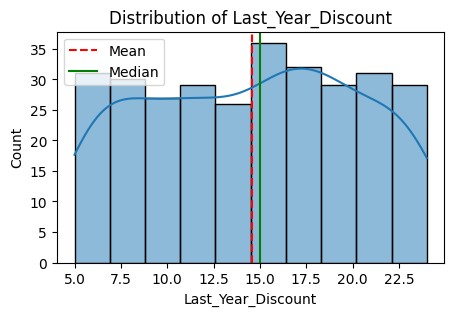

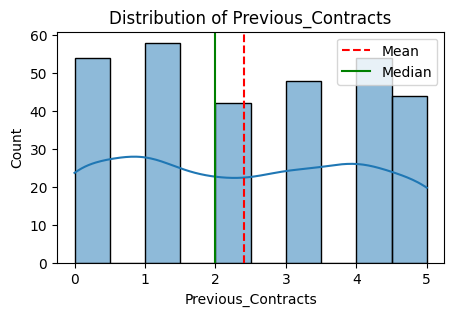

In [10]:
plot_histogram(df, "Last_Year_Discount")
plot_histogram(df, "Previous_Contracts")

In [11]:
def plot_boxplot(df, column_name):

  plt.figure(figsize=(5, 3))
  sns.boxplot(y=df[column_name])
  plt.title(f"Box Plot of {column_name}")
  plt.ylabel(column_name)
  plt.show()

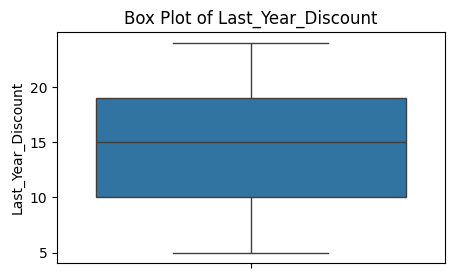

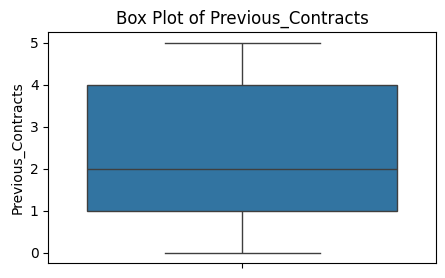

In [12]:
plot_boxplot(df, "Last_Year_Discount")
plot_boxplot(df, "Previous_Contracts")

In [ ]:
#STEP 4 — SPLIT TARGET & FEATURES (IMPORTANT ORDER)

In [13]:
# Target
y = df["Renewal"].map({"No": 0, "Yes": 1})

# Features
X = df.drop(["Customer_ID", "Serial_No", "Renewal"], axis=1)


In [ ]:
#STEP 5 — ENCODING (ONLY FEATURES)

In [14]:
X = pd.get_dummies(X, drop_first=True)

In [16]:
X.head()

,Last_Year_Discount,Previous_Contracts,Contract_Duration,Is_Long_Contract,High_Discount,Loyal_Customer,Product_Type_Monitor,Product_Type_Printer,Contract_Status_Expired,Support_Package_Premium,Support_Package_Standard,Warranty_Yes
0,18,4,734,1,1,1,True,False,False,False,False,True
1,17,0,402,1,1,0,False,False,True,False,True,False
2,16,0,721,1,1,0,True,False,False,True,False,True
3,11,3,605,1,0,1,True,False,False,False,True,False
4,6,3,397,1,0,1,False,False,True,False,True,False


In [17]:
y.head()

0    1
1    0
2    0
3    0
4    0
Name: Renewal, dtype: int64

In [18]:
print("Columns:", df.columns)
print("Target exists:", "Renewal" in df.columns)

Columns: Index(['Customer_ID', 'Serial_No', 'Product_Type', 'Contract_Status',
       'Support_Package', 'Warranty', 'Last_Year_Discount',
       'Previous_Contracts', 'Renewal', 'Contract_Duration',
       'Is_Long_Contract', 'High_Discount', 'Loyal_Customer'],
      dtype='object')
Target exists: True


In [ ]:
#STEP 6 — TRAIN TEST SPLIT

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
print(y_train.shape)

(240,)


In [21]:
print(y_train.value_counts())

Renewal
0    143
1     97
Name: count, dtype: int64


In [22]:
print(df["Renewal"].value_counts())


Renewal
No     176
Yes    124
Name: count, dtype: int64


In [ ]:
#STEP 7 — HANDLE IMBALANCE (SMOTE)

In [23]:
%pip install --upgrade "scikit-learn==1.2.2" "imbalanced-learn==0.10.1"



Note: you may need to restart the kernel to use updated packages.


In [24]:
from imblearn.over_sampling import SMOTE

In [25]:
smote = SMOTE(random_state=42)

In [26]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [27]:
print(y_train_smote.shape)

(286,)


In [28]:
print(y_train_smote.value_counts())

Renewal
0    143
1    143
Name: count, dtype: int64


In [29]:
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: Renewal
0    143
1     97
Name: count, dtype: int64
After SMOTE: Renewal
0    143
1    143
Name: count, dtype: int64


In [ ]:
# STEP 9 — TRAIN MODEL

In [41]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [42]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(random_state=42)
}

cv_scores = {}

for model_name, model in models.items():
    print(f"Training {model_name}")
    
    scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring="accuracy")
    
    cv_scores[model_name] = scores
    
    print(f"{model_name} CV Accuracy: {np.mean(scores):.2f}")
    print("-"*50)


Training Decision Tree
Decision Tree CV Accuracy: 0.54
--------------------------------------------------
Training Random Forest
Random Forest CV Accuracy: 0.62
--------------------------------------------------
Training XGBoost
XGBoost CV Accuracy: 0.67
--------------------------------------------------


In [ ]:
# Step 10: FINAL MODEL (XGBOOST)

In [44]:
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


In [ ]:
# Step 11. TRAIN MODEL

In [45]:
model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [46]:
# Step 12. PREDICTION

In [47]:
y_prob = model.predict_proba(X_test)[:, 1]

# Custom threshold (important)
y_pred = (y_prob > 0.4).astype(int)


In [ ]:
# Step 13. EVALUATION

In [49]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.5333333333333333

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.61      0.59        33
           1       0.48      0.44      0.46        27

    accuracy                           0.53        60
   macro avg       0.53      0.53      0.52        60
weighted avg       0.53      0.53      0.53        60



In [50]:
# Step 14. FEATURE IMPORTANCE

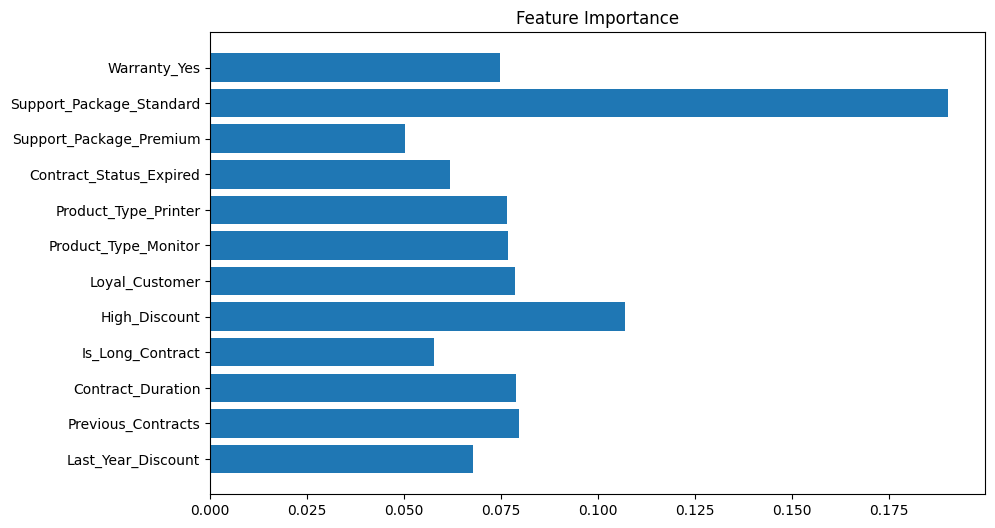

In [51]:
importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()


In [52]:
#Step 15 BUSINESS LOGIC (MAIN OUTPUT)

In [53]:
full_prob = model.predict_proba(X)[:, 1]

df["Renewal_Probability"] = full_prob

df["Suggested_Discount"] = (1 - full_prob) * 20

print(df[["Customer_ID", "Renewal_Probability", "Suggested_Discount"]].head())


  Customer_ID  Renewal_Probability  Suggested_Discount
0       C0001             0.815157            3.696867
1       C0002             0.081893           18.362148
2       C0003             0.152493           16.950150
3       C0004             0.119185           17.616301
4       C0005             0.286381           14.272387


In [54]:
# Step 16. SAVE MODEL


In [55]:
pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(X.columns, open("features.pkl", "wb"))
